[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/huythanh1324/sutd-stat/blob/main/data.ipynb)

# Singapore PM2.5 × regional fires × local weather — data crawl & data dictionary

**Project question:** Do satellite fire detections and local meteorological conditions improve short-horizon prediction of high-PM2.5 periods in Singapore beyond persistence and seasonality?

This notebook only does **step 1**: crawl the three authoritative sources and understand *what each table is* and *what every column means*. No modelling yet.

| # | Source | Endpoint | Table(s) produced |
|---|--------|----------|-------------------|
| 1 | NEA PM2.5 (data.gov.sg) | `GET /v2/real-time/api/pm25` | `pm25_regions`, `pm25` |
| 2 | NEA weather, collection 1459 (data.gov.sg) | `GET /v2/real-time/api/{air-temperature, relative-humidity, wind-speed, wind-direction, rainfall}` | `weather_stations`, `weather` |
| 3 | NASA FIRMS active fires | `GET /api/area/csv/{MAP_KEY}/{SOURCE}/{bbox}/{days}/{date}` | `firms` |

**Sample window:** mid-Sep → Oct 2023, which contains the Oct-2023 transboundary haze episode, so we can actually see high PM2.5 values.

## 0. Setup & configuration

In [ ]:
# ---------------- Google Colab setup (skipped when running locally) ----------------
# On Colab: mount Google Drive and work inside a Drive folder, so the data/raw cache survives runtime restarts.
# API keys come from Colab Secrets (key icon in the left sidebar): add FIRMS_MAP_KEY (and optionally DATAGOV_API_KEY)
# and switch on "Notebook access". Copying your local data/raw/ into <PROJECT>/data/raw/ skips the slow crawl.
import os
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT = "/content/drive/MyDrive/claude-projects/sutd-stat"
    os.makedirs(PROJECT, exist_ok=True)
    os.chdir(PROJECT)
print("Colab:", IN_COLAB, "| working dir:", os.getcwd())

In [1]:
import os, io, time, json
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

In [2]:
# ---------------- configuration ----------------
START, END = "2023-09-15", "2023-10-31"                 # PM2.5 + FIRMS sample window
# The weather API returns 1-minute readings, 25 timestamps per page (~58 requests per day per variable)
# and data.gov.sg rate-limits anonymous users (~9 min per day for all 5 variables), so weather gets its own shorter window.
WEATHER_START, WEATHER_END = "2023-10-01", "2023-10-07"

BBOX = (95, -6, 120, 8)          # west, south, east, north  -> Sumatra + Kalimantan + Peninsular Malaysia
SGT = "Asia/Singapore"

RAW = Path("data/raw"); RAW.mkdir(parents=True, exist_ok=True)

def load_dotenv(path=".env"):
    # minimal .env reader (KEY=VALUE lines), so we don't need python-dotenv
    p = Path(path)
    if p.exists():
        for line in p.read_text().splitlines():
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                k, v = line.split("=", 1)
                os.environ.setdefault(k.strip(), v.strip().strip('"').strip("'"))

load_dotenv()
if IN_COLAB:
    from google.colab import userdata
    for k in ("FIRMS_MAP_KEY", "DATAGOV_API_KEY"):
        try:
            os.environ.setdefault(k, userdata.get(k) or "")
        except Exception:                                   # secret not defined, or notebook access not granted
            pass
FIRMS_MAP_KEY   = os.environ.get("FIRMS_MAP_KEY", "")     # https://firms.modaps.eosdis.nasa.gov/api/map_key/
DATAGOV_API_KEY = os.environ.get("DATAGOV_API_KEY", "")   # optional; raises data.gov.sg rate limit
print("FIRMS key set:", bool(FIRMS_MAP_KEY), "| data.gov.sg key set:", bool(DATAGOV_API_KEY))

FIRMS key set: True | data.gov.sg key set: False


In [3]:
DATAGOV = "https://api-open.data.gov.sg/v2/real-time/api"

session = requests.Session()
if DATAGOV_API_KEY:
    session.headers["x-api-key"] = DATAGOV_API_KEY

def get_json(url, params=None, max_tries=10):
    # GET with exponential back-off on HTTP 429 (rate limit) and transient errors
    for i in range(max_tries):
        try:
            r = session.get(url, params=params, timeout=60)
        except requests.RequestException:
            time.sleep(min(2 ** i, 60)); continue
        if r.status_code == 429 or r.status_code >= 500:
            time.sleep(min(2 ** i, 60)); continue
        if r.status_code == 404:                  # code 17 REAL_TIME_API_DATA_NOT_FOUND: no data that day
            print(f"  no data: {url.rsplit('/', 1)[-1]} {params}")
            return {}
        r.raise_for_status()
        js = r.json()
        if js.get("code", 0) != 0 or js.get("data") is None:
            raise RuntimeError(f"API error for {url} {params}: {js}")
        return js["data"]
    raise RuntimeError(f"Gave up after {max_tries} tries: {url} {params}")

def get_all_pages(endpoint, date, pause=0.3):
    # data.gov.sg v2 paginates with `paginationToken`; follow it until it disappears
    pages, token = [], None
    while True:
        params = {"date": date}
        if token:
            params["paginationToken"] = token
        data = get_json(f"{DATAGOV}/{endpoint}", params)
        pages.append(data)
        token = data.get("paginationToken")
        if not token:
            return pages
        time.sleep(pause)

def days(start, end):
    return [d.strftime("%Y-%m-%d") for d in pd.date_range(start, end, freq="D")]

def to_sgt(s):
    return pd.to_datetime(s, utc=True).dt.tz_convert(SGT)

def profile(df, name, time_col=None):
    # quick structural summary used for every table
    print(f"=== {name}: {df.shape[0]:,} rows x {df.shape[1]} cols ===")
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(),
        "example": df.iloc[0] if len(df) else None,
    })
    display(summary)
    print("duplicate rows:", df.duplicated().sum())
    if time_col is not None:
        t = df[time_col]
        print(f"time range: {t.min()} -> {t.max()}")
        print("most common spacing between consecutive distinct timestamps:")
        display(t.drop_duplicates().sort_values().diff().value_counts().head(5))

## 1. NEA PM2.5 (`/v2/real-time/api/pm25`)

One request per day (`?date=YYYY-MM-DD`). The JSON response has two parts:
* `data.regionMetadata`: the 5 reporting regions and the map coordinates of their labels.
* `data.items[]`: one item per hour, with `readings.pm25_one_hourly = {region: value}`.

We flatten it into two tidy tables.

In [4]:
def crawl_pm25(start, end):
    f_read, f_reg = RAW / f"pm25_{start}_{end}.csv", RAW / "pm25_regions.csv"
    if f_read.exists() and f_reg.exists():
        return pd.read_csv(f_reg), pd.read_csv(f_read)
    rows, regions = [], {}
    for d in days(start, end):
        for page in get_all_pages("pm25", d):
            for r in page.get("regionMetadata", []):
                regions[r["name"]] = {"region": r["name"],
                                      "label_lat": r["labelLocation"]["latitude"],
                                      "label_lon": r["labelLocation"]["longitude"]}
            for it in page.get("items", []):
                for metric, by_region in it["readings"].items():
                    for reg, val in by_region.items():
                        rows.append({"date": it["date"], "timestamp": it["timestamp"],
                                     "updatedTimestamp": it["updatedTimestamp"],
                                     "metric": metric, "region": reg, "value": val})
    reg_df, pm_df = pd.DataFrame(regions.values()), pd.DataFrame(rows)
    reg_df.to_csv(f_reg, index=False); pm_df.to_csv(f_read, index=False)
    return reg_df, pm_df

pm25_regions, pm25 = crawl_pm25(START, END)
pm25["timestamp"] = to_sgt(pm25["timestamp"])
pm25["updatedTimestamp"] = to_sgt(pm25["updatedTimestamp"])
pm25_regions

,region,label_lat,label_lon
0,west,1.35735,103.70
1,east,1.35735,103.94
2,central,1.35735,103.82
3,south,1.29587,103.82
4,north,1.41803,103.82


In [5]:
pm25.head(10)

,date,timestamp,updatedTimestamp,metric,region,value
0,2023-09-15,2023-09-15 23:00:00+08:00,2024-07-18 12:27:11+08:00,pm25_one_hourly,west,17
1,2023-09-15,2023-09-15 23:00:00+08:00,2024-07-18 12:27:11+08:00,pm25_one_hourly,east,32
2,2023-09-15,2023-09-15 23:00:00+08:00,2024-07-18 12:27:11+08:00,pm25_one_hourly,central,29
3,2023-09-15,2023-09-15 23:00:00+08:00,2024-07-18 12:27:11+08:00,pm25_one_hourly,south,21
4,2023-09-15,2023-09-15 23:00:00+08:00,2024-07-18 12:27:11+08:00,pm25_one_hourly,north,13
5,2023-09-15,2023-09-15 22:00:00+08:00,2024-07-18 12:27:10+08:00,pm25_one_hourly,west,21
6,2023-09-15,2023-09-15 22:00:00+08:00,2024-07-18 12:27:10+08:00,pm25_one_hourly,east,37
7,2023-09-15,2023-09-15 22:00:00+08:00,2024-07-18 12:27:10+08:00,pm25_one_hourly,central,32
8,2023-09-15,2023-09-15 22:00:00+08:00,2024-07-18 12:27:10+08:00,pm25_one_hourly,south,20
9,2023-09-15,2023-09-15 22:00:00+08:00,2024-07-18 12:27:10+08:00,pm25_one_hourly,north,13


In [6]:
profile(pm25, "pm25", time_col="timestamp")
print("metrics:", pm25["metric"].unique())

=== pm25: 5,365 rows x 6 cols ===


,dtype,n_missing,pct_missing,n_unique,example
date,str,0,0.0,46,2023-09-15
timestamp,"datetime64[us, Asia/Singapore]",0,0.0,1073,2023-09-15 23:00:00+08:00
updatedTimestamp,"datetime64[us, Asia/Singapore]",0,0.0,379,2024-07-18 12:27:11+08:00
metric,str,0,0.0,1,pm25_one_hourly
region,str,0,0.0,5,west
value,int64,0,0.0,74,17


duplicate rows: 0
time range: 2023-09-15 00:00:00+08:00 -> 2023-10-31 23:00:00+08:00
most common spacing between consecutive distinct timestamps:


timestamp
0 days 01:00:00    1068
0 days 05:00:00       1
0 days 04:00:00       1
2 days 00:00:00       1
0 days 02:00:00       1
Name: count, dtype: int64

metrics: <StringArray>
['pm25_one_hourly']
Length: 1, dtype: str


### PM2.5 data dictionary

**`pm25_regions`**: one row per reporting region.

| column | meaning |
|---|---|
| `region` | One of `north`, `south`, `east`, `west`, `central`. NEA reports PM2.5 for 5 regions of Singapore, not for individual stations. |
| `label_lat`, `label_lon` | Where NEA places the region label on a map. This is **not** the monitor location, only a representative point for the region. |

**`pm25`**: long format, one row per (hour × region).

| column | meaning |
|---|---|
| `date` | Calendar date (SGT) we requested. |
| `timestamp` | Time the reading refers to, in SGT (+08:00). The hour is the **end** of the 1-hour averaging window, so 14:00 = mean over 13:00–14:00. |
| `updatedTimestamp` | When NEA last wrote/updated the record. For historical data this is a back-fill date (e.g. 2024), so it is useless for modelling but tells you the data were revised after the fact. |
| `metric` | The reading name. Here it is always `pm25_one_hourly`. |
| `region` | Region key, which joins to `pm25_regions.region`. |
| `value` | PM2.5 concentration, **µg/m³, 1-hour mean**. This is *not* the 24-h PSI and not the 15-min raw data. NEA's 1-h PM2.5 bands are: Band I Normal 0–55, Band II Elevated 56–150, Band III High 151–250, Band IV Very High ≥251. |

> **Note vs. project brief:** the brief mentions 15-minute readings, but the public API only exposes **hourly** values. Check the "spacing" table above. Some hours are missing on some days, so the time grid has gaps.

In [7]:
# How many hourly records per day (should be 24 x 5 regions = 120)?
per_day = pm25.groupby("date")["value"].size()
print(per_day.describe())
print("\ndays with fewer than 120 rows:"); display(per_day[per_day < 120])

count     46.000000
mean     116.630435
std       12.340284
min       55.000000
25%      120.000000
50%      120.000000
75%      120.000000
max      120.000000
Name: value, dtype: float64

days with fewer than 120 rows:


date
2023-10-05    100
2023-10-06    105
2023-10-07     55
2023-10-09     70
2023-10-31    115
Name: value, dtype: int64

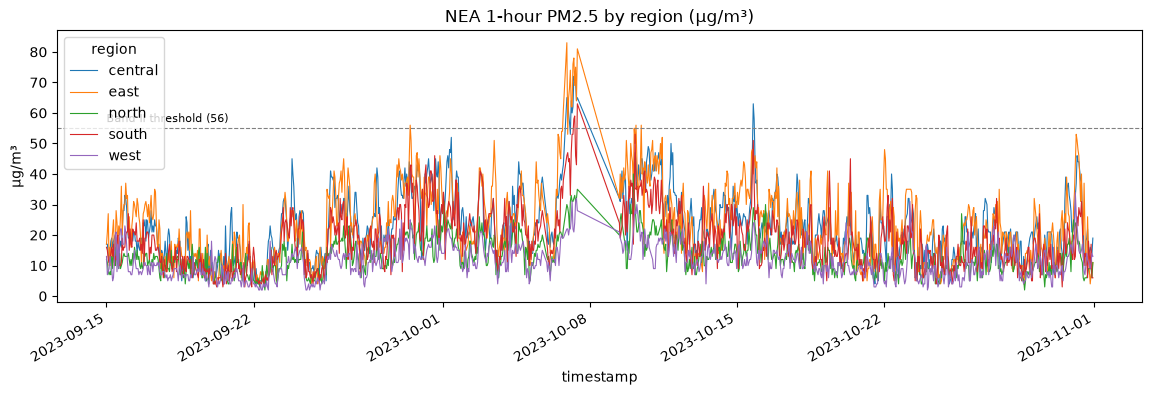

region,central,east,north,south,west
count,1073.0,1073.0,1073.0,1073.0,1073.0
mean,22.9,23.8,13.2,18.4,11.5
std,11.1,12.3,5.7,9.3,5.3
min,3.0,4.0,2.0,3.0,2.0
25%,15.0,14.0,9.0,12.0,8.0
50%,21.0,22.0,12.0,17.0,11.0
75%,29.0,31.0,17.0,24.0,15.0
max,72.0,83.0,40.0,63.0,34.0


In [8]:
wide = pm25.pivot_table(index="timestamp", columns="region", values="value")
ax = wide.plot(figsize=(14, 4), lw=0.8, title="NEA 1-hour PM2.5 by region (µg/m³)")
ax.axhline(55, ls="--", c="grey", lw=0.8); ax.text(wide.index[0], 57, "Band II threshold (56)", fontsize=8)
ax.set_ylabel("µg/m³"); plt.show()
display(wide.describe().round(1))

## 2. NEA weather, collection 1459 (`/v2/real-time/api/<variable>`)

Every weather endpoint returns the same JSON shape:
* `data.stations[]`: station metadata (`id`, `deviceId`, `name`, `location.latitude/longitude`).
* `data.readings[]`: one entry per timestamp, with `data: [{stationId, value}, ...]`.
* `data.readingType`, `data.readingUnit`: what the value measures and its unit.
* `data.paginationToken`: there are only 25 timestamps per page, so we have to follow it.

Results are cached **one file per variable per day** under `data/raw/weather/`, so an interrupted crawl just resumes.

In [9]:
WEATHER_ENDPOINTS = ["air-temperature", "relative-humidity", "wind-speed", "wind-direction", "rainfall"]

def crawl_weather_day(endpoint, date):
    d = RAW / "weather" / endpoint; d.mkdir(parents=True, exist_ok=True)
    f_read, f_sta = d / f"{date}.csv.gz", d / f"{date}_stations.csv"
    if f_read.exists() and f_sta.exists():
        return pd.read_csv(f_read), pd.read_csv(f_sta)
    rows, stations, rtype, runit = [], {}, None, None
    for page in get_all_pages(endpoint, date):
        rtype = rtype or page.get("readingType"); runit = runit or page.get("readingUnit")
        for s in page.get("stations", []):
            stations[s["id"]] = {"stationId": s["id"], "deviceId": s.get("deviceId"), "name": s.get("name"),
                                 "lat": s["location"]["latitude"], "lon": s["location"]["longitude"]}
        for r in page.get("readings", []):
            for x in r["data"]:
                rows.append((r["timestamp"], x["stationId"], x["value"]))
    df = pd.DataFrame(rows, columns=["timestamp", "stationId", "value"])
    df["variable"], df["readingType"], df["readingUnit"] = endpoint, rtype, runit
    sta = pd.DataFrame(stations.values()); sta["variable"], sta["date"] = endpoint, date
    df.to_csv(f_read, index=False); sta.to_csv(f_sta, index=False)
    return df, sta

def crawl_weather(start, end, endpoints=WEATHER_ENDPOINTS):
    reads, stas = [], []
    for ep in endpoints:
        for d in days(start, end):
            t0 = time.time()
            r, s = crawl_weather_day(ep, d)
            reads.append(r); stas.append(s)
            print(f"{ep:18s} {d}  {len(r):>7,} rows  ({time.time() - t0:.1f}s)", flush=True)
    return pd.concat(reads, ignore_index=True), pd.concat(stas, ignore_index=True)

weather, weather_stations_daily = crawl_weather(WEATHER_START, WEATHER_END)
weather["timestamp"] = to_sgt(weather["timestamp"])
weather.head()

air-temperature    2023-10-01   18,255 rows  (0.0s)
air-temperature    2023-10-02   18,586 rows  (0.0s)
air-temperature    2023-10-03   18,501 rows  (0.0s)
air-temperature    2023-10-04   18,573 rows  (0.0s)
air-temperature    2023-10-05   18,572 rows  (0.0s)
air-temperature    2023-10-06   18,578 rows  (0.0s)
air-temperature    2023-10-07   18,121 rows  (0.0s)
relative-humidity  2023-10-01   18,255 rows  (0.0s)
relative-humidity  2023-10-02   18,586 rows  (0.0s)
relative-humidity  2023-10-03   18,501 rows  (0.0s)
relative-humidity  2023-10-04   18,573 rows  (0.0s)
relative-humidity  2023-10-05   18,572 rows  (0.0s)
relative-humidity  2023-10-06   18,578 rows  (0.0s)
relative-humidity  2023-10-07   18,121 rows  (0.0s)
wind-speed         2023-10-01   16,805 rows  (0.0s)
wind-speed         2023-10-02   17,148 rows  (0.0s)
wind-speed         2023-10-03   17,051 rows  (0.0s)
wind-speed         2023-10-04   17,135 rows  (0.0s)
wind-speed         2023-10-05   17,135 rows  (0.0s)
wind-speed  

,timestamp,stationId,value,variable,readingType,readingUnit
0,2023-10-01 23:59:00+08:00,S109,28.5,air-temperature,DBT 1M F,deg C
1,2023-10-01 23:59:00+08:00,S117,28.3,air-temperature,DBT 1M F,deg C
2,2023-10-01 23:59:00+08:00,S50,28.0,air-temperature,DBT 1M F,deg C
3,2023-10-01 23:59:00+08:00,S107,29.4,air-temperature,DBT 1M F,deg C
4,2023-10-01 23:59:00+08:00,S43,28.7,air-temperature,DBT 1M F,deg C


In [10]:
# what each variable is, its unit and its sampling interval
spacing = (weather.drop_duplicates(["variable", "timestamp"]).sort_values("timestamp")
           .groupby("variable")["timestamp"].apply(lambda t: t.diff().mode().iloc[0]))
var_summary = (weather.groupby("variable")
               .agg(readingType=("readingType", "first"), unit=("readingUnit", "first"),
                    n_rows=("value", "size"), n_stations=("stationId", "nunique"),
                    min=("value", "min"), median=("value", "median"), max=("value", "max"))
               .join(spacing.rename("sampling_interval")))
var_summary

,readingType,unit,n_rows,n_stations,min,median,max,sampling_interval
variable,,,,,,,,
air-temperature,DBT 1M F,deg C,129186,13,23.9,28.9,35.3,0 days 00:01:00
rainfall,TB1 Rainfall 5 Minute Total F,mm,132866,66,0.0,0.0,6.2,0 days 00:05:00
relative-humidity,RH 1M F,percentage,129186,13,37.4,76.4,99.2,0 days 00:01:00
wind-direction,Wind Dir AVG (S) 10M M1M,degrees,119004,12,1.0,142.0,359.0,0 days 00:01:00
wind-speed,Wind Speed AVG(S)10M M1M,knots,119097,12,0.2,4.5,21.8,0 days 00:01:00


In [11]:
profile(weather, "weather (long)", time_col="timestamp")

=== weather (long): 629,339 rows x 6 cols ===


,dtype,n_missing,pct_missing,n_unique,example
timestamp,"datetime64[us, Asia/Singapore]",0,0.0,10073,2023-10-01 23:59:00+08:00
stationId,str,0,0.0,66,S109
value,float64,0,0.0,1216,28.5
variable,str,0,0.0,5,air-temperature
readingType,str,0,0.0,5,DBT 1M F
readingUnit,str,0,0.0,5,deg C


duplicate rows: 0
time range: 2023-10-01 00:00:00+08:00 -> 2023-10-07 23:59:00+08:00
most common spacing between consecutive distinct timestamps:


timestamp
0 days 00:01:00    10065
0 days 00:02:00        7
Name: count, dtype: int64

In [12]:
# station table: one row per station, with the list of variables it reports
weather_stations = (weather_stations_daily
                    .groupby(["stationId", "name", "lat", "lon"], as_index=False)
                    .agg(variables=("variable", lambda v: ", ".join(sorted(set(v)))),
                         n_variables=("variable", "nunique")))
print(len(weather_stations), "distinct stations")
display(weather_stations["n_variables"].value_counts().rename("stations reporting N variables"))
weather_stations.sort_values("n_variables", ascending=False).head(15)

66 distinct stations


n_variables
1    53
5    12
3     1
Name: stations reporting N variables, dtype: int64

,stationId,name,lat,lon,variables,n_variables
3,S107,East Coast Parkway,1.31350,103.96250,"air-temperature, rainfall, relative-humidity, ...",5
2,S104,Woodlands Avenue 9,1.44387,103.78538,"air-temperature, rainfall, relative-humidity, ...",5
50,S50,Clementi Road,1.33370,103.77680,"air-temperature, rainfall, relative-humidity, ...",5
51,S60,Sentosa,1.25000,103.82790,"air-temperature, rainfall, relative-humidity, ...",5
4,S109,Ang Mo Kio Avenue 5,1.37640,103.84920,"air-temperature, rainfall, relative-humidity, ...",5
5,S111,Scotts Road,1.31055,103.83650,"air-temperature, rainfall, relative-humidity, ...",5
9,S115,Tuas South Avenue 3,1.29377,103.61843,"air-temperature, rainfall, relative-humidity, ...",5
15,S121,Old Choa Chu Kang Road,1.37288,103.72244,"air-temperature, rainfall, relative-humidity, ...",5
11,S117,Banyan Road,1.25600,103.67900,"air-temperature, rainfall, relative-humidity, ...",5
10,S116,West Coast Highway,1.28100,103.75400,"air-temperature, rainfall, relative-humidity, ...",5


### Weather data dictionary

**`weather_stations`**: one row per NEA automatic weather station.

| column | meaning |
|---|---|
| `stationId` | NEA station code (e.g. `S109`), which joins to `weather.stationId`. |
| `deviceId` | Device code. Equal to `stationId` in practice. |
| `name` | Road/place where the station is. |
| `lat`, `lon` | Station location (WGS84). |
| `variables` | Which of the 5 variables this station reports. Most stations are **rain gauges only**; only around 10–15 stations measure temperature, humidity or wind. |

**`weather`**: long format, one row per (timestamp × station × variable).

| column | meaning |
|---|---|
| `timestamp` | End of the measurement interval, SGT. |
| `stationId` | Station code. |
| `value` | Measured value, in the unit below. |
| `variable` | Endpoint name. |
| `readingType` | NEA's internal description of the measurement (see the table above). |
| `readingUnit` | Unit. |

| variable | what it measures | unit | interval | how to aggregate to hourly |
|---|---|---|---|---|
| `air-temperature` | Dry-bulb air temperature | °C | 1 min | mean |
| `relative-humidity` | Relative humidity | % | 1 min | mean |
| `wind-speed` | Wind speed, rolling **10-min average**, reported every minute | **knots** (×0.514 → m/s) | 1 min | mean |
| `wind-direction` | Direction the wind blows **from**, 10-min average | degrees (0/360 = N, 90 = E) | 1 min | **vector mean** (never the arithmetic mean of angles) |
| `rainfall` | Rain that fell in the last 5 minutes | mm | 5 min | **sum** |

Why wind matters here: Singapore is downwind of Sumatra during the **south-west monsoon (Jun–Sep/Oct)** and downwind of Kalimantan/S. China Sea in other periods. Wind direction is therefore the main physical link between a regional fire and local PM2.5.

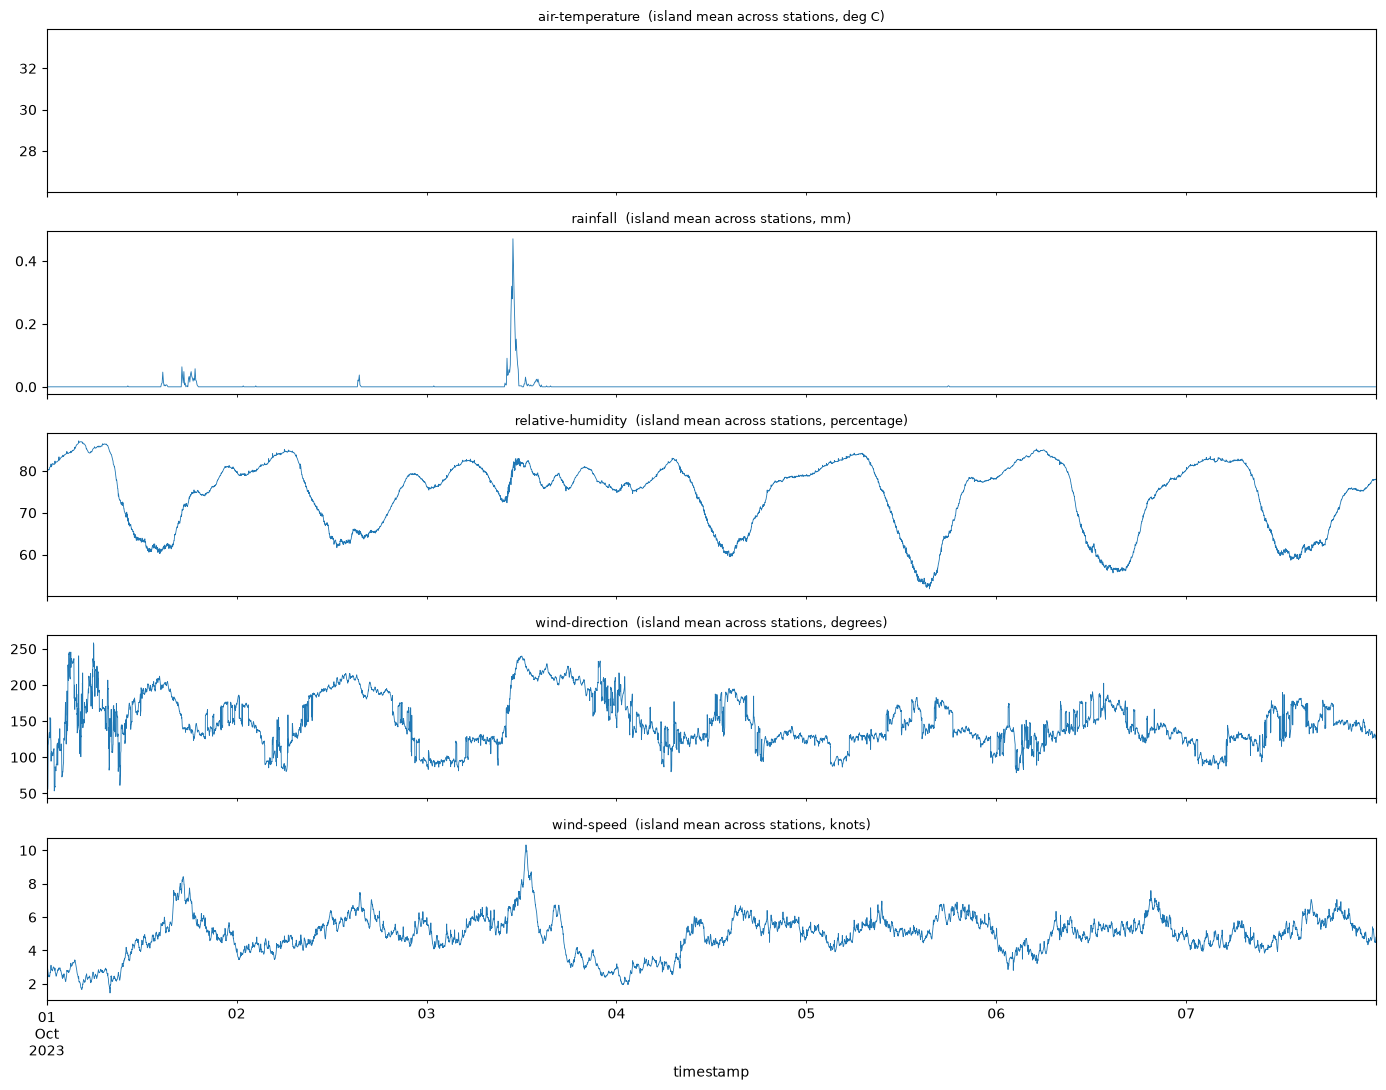

In [13]:
fig, axes = plt.subplots(len(WEATHER_ENDPOINTS), 1, figsize=(14, 11), sharex=True)
for ax, (var, g) in zip(axes, weather.groupby("variable")):
    g.groupby("timestamp")["value"].mean().plot(ax=ax, lw=0.6)
    ax.set_title(f"{var}  (island mean across stations, {g['readingUnit'].iloc[0]})", fontsize=9)
plt.tight_layout(); plt.show()

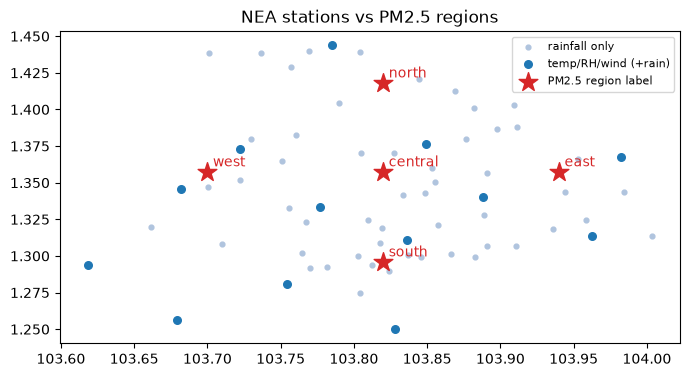

In [14]:
# Where are the weather stations relative to the PM2.5 region label points?
fig, ax = plt.subplots(figsize=(8, 5))
rain_only = weather_stations["n_variables"] == 1
ax.scatter(weather_stations.loc[rain_only, "lon"], weather_stations.loc[rain_only, "lat"], s=12, c="lightsteelblue", label="rainfall only")
ax.scatter(weather_stations.loc[~rain_only, "lon"], weather_stations.loc[~rain_only, "lat"], s=30, c="tab:blue", label="temp/RH/wind (+rain)")
ax.scatter(pm25_regions["label_lon"], pm25_regions["label_lat"], marker="*", s=200, c="tab:red", label="PM2.5 region label")
for _, r in pm25_regions.iterrows():
    ax.annotate(r["region"], (r["label_lon"], r["label_lat"]), xytext=(4, 4), textcoords="offset points", color="tab:red")
ax.set_aspect("equal"); ax.legend(fontsize=8); ax.set_title("NEA stations vs PM2.5 regions"); plt.show()

## 3. NASA FIRMS active fires (`/api/area/csv/...`)

FIRMS gives one row per **satellite pixel flagged as containing an active fire (thermal anomaly)** at the moment of an overpass. The data come as several *sources*, one per sensor and processing level:

| source | sensor / satellite | pixel | processing |
|---|---|---|---|
| `MODIS_NRT` / `MODIS_SP` | MODIS on Terra + Aqua | ~1 km | NRT = near-real-time (~3 h latency); SP = standard/science-quality (reprocessed, arrives months later) |
| `VIIRS_SNPP_NRT` / `VIIRS_SNPP_SP` | VIIRS on Suomi-NPP | 375 m | same |
| `VIIRS_NOAA20_NRT` / `VIIRS_NOAA20_SP` | VIIRS on NOAA-20 | 375 m | same |
| `VIIRS_NOAA21_NRT` | VIIRS on NOAA-21 | 375 m | NRT only (2024+) |

The API serves NRT only for recent months. Older dates are served as SP, so for a 2023 window we expect the `*_NRT` sources to come back mostly empty. The availability table below shows the exact date ranges.

The area API returns at most **5 days per request** (`/{days}/{start_date}`), so we loop in 5-day chunks.

In [15]:
FIRMS = "https://firms.modaps.eosdis.nasa.gov/api"
FIRMS_SOURCES = ["MODIS_SP", "VIIRS_SNPP_SP", "VIIRS_NOAA20_SP", "MODIS_NRT", "VIIRS_SNPP_NRT", "VIIRS_NOAA20_NRT"]

def firms_get_csv(url):
    for i in range(6):
        r = requests.get(url, timeout=180)
        if r.status_code == 429 or r.status_code >= 500:
            time.sleep(min(2 ** i, 60)); continue
        txt = r.text
        if r.status_code in (400, 401, 403) and "MAP_KEY" in txt:
            raise RuntimeError(f"FIRMS rejected the MAP_KEY: {txt.strip()[:120]} -> check FIRMS_MAP_KEY in .env (keys are 32 chars)")
        r.raise_for_status()
        if not txt.strip() or "," not in txt.splitlines()[0]:     # FIRMS returns plain-text errors with HTTP 200
            raise RuntimeError(f"FIRMS error: {txt[:200]}")
        return pd.read_csv(io.StringIO(txt))
    raise RuntimeError(f"Gave up: {url}")

FIRMS_OK = False
if FIRMS_MAP_KEY:
    try:
        firms_availability = firms_get_csv(f"{FIRMS}/data_availability/csv/{FIRMS_MAP_KEY}/ALL")
        FIRMS_OK = True
        display(firms_availability)
    except RuntimeError as e:
        print(e, "| Skipping FIRMS cells.")
else:
    print("FIRMS_MAP_KEY not set: skipping FIRMS cells. Put FIRMS_MAP_KEY=... in .env")

FIRMS rejected the MAP_KEY: Invalid MAP_KEY. -> check FIRMS_MAP_KEY in .env (keys are 32 chars) | Skipping FIRMS cells.


In [16]:
def crawl_firms(source, start, end, bbox=BBOX, chunk=5):
    f = RAW / "firms" / f"{source}_{start}_{end}.csv"; f.parent.mkdir(parents=True, exist_ok=True)
    if f.exists():
        return pd.read_csv(f)
    area = ",".join(str(x) for x in bbox)
    frames = []
    for d0 in pd.date_range(start, end, freq=f"{chunk}D"):
        n = min(chunk, (pd.Timestamp(end) - d0).days + 1)
        df = firms_get_csv(f"{FIRMS}/area/csv/{FIRMS_MAP_KEY}/{source}/{area}/{n}/{d0:%Y-%m-%d}")
        frames.append(df)
    out = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    out.insert(0, "source", source)
    out.to_csv(f, index=False)
    return out

firms_by_source = {}
if FIRMS_OK:
    for src in FIRMS_SOURCES:
        firms_by_source[src] = crawl_firms(src, START, END)
        print(f"{src:18s} {len(firms_by_source[src]):>7,} detections")

In [17]:
# Column sets differ between MODIS and VIIRS: show them side by side
if firms_by_source:
    cols = {s: list(df.columns) for s, df in firms_by_source.items() if len(df)}
    all_cols = list(dict.fromkeys(c for v in cols.values() for c in v))
    display(pd.DataFrame({s: ["✓" if c in v else "" for c in all_cols] for s, v in cols.items()}, index=all_cols))

In [18]:
if firms_by_source:
    firms = pd.concat([df for df in firms_by_source.values() if len(df)], ignore_index=True)
    firms["instrument_family"] = np.where(firms["source"].str.startswith("MODIS"), "MODIS", "VIIRS")
    # acq_date + acq_time (HHMM, UTC) -> timezone-aware datetime, then SGT
    firms["acq_datetime_utc"] = pd.to_datetime(firms["acq_date"] + " " + firms["acq_time"].astype(str).str.zfill(4),
                                               format="%Y-%m-%d %H%M").dt.tz_localize("UTC")
    firms["acq_datetime_sgt"] = firms["acq_datetime_utc"].dt.tz_convert(SGT)
    display(firms.head())
    for fam, g in firms.groupby("instrument_family"):
        profile(g.dropna(axis=1, how="all"), f"firms – {fam}", time_col="acq_datetime_utc")

### FIRMS data dictionary

| column | MODIS | VIIRS | meaning |
|---|:-:|:-:|---|
| `source` | ✓ | ✓ | Added by us: which API source (sensor + NRT/SP) the row came from. |
| `latitude`, `longitude` | ✓ | ✓ | **Centre of the fire pixel**, not the exact fire location. The fire is somewhere inside a ~1 km (MODIS) or ~375 m (VIIRS) pixel. |
| `brightness` | ✓ | | MODIS channel 21/22 (4 µm) brightness temperature of the pixel, **Kelvin**. Hotter means a stronger thermal anomaly. |
| `bright_ti4` | | ✓ | VIIRS I-4 channel (3.7 µm) brightness temperature, K. This is the VIIRS equivalent of `brightness`; it saturates around 367 K. |
| `bright_t31` | ✓ | | MODIS channel 31 (11 µm) brightness temperature, K. It measures the background, not the fire. |
| `bright_ti5` | | ✓ | VIIRS I-5 channel (11 µm) brightness temperature, K. Also background. |
| `scan`, `track` | ✓ | ✓ | Actual pixel size in km along-scan and along-track. Pixels grow towards the swath edge (MODIS: 1 km at nadir → ~4.8 km × 2 km at the edge), so **edge-of-swath detections cover more area**. |
| `acq_date` | ✓ | ✓ | Acquisition date, **UTC**. |
| `acq_time` | ✓ | ✓ | Acquisition time, **UTC**, as an HHMM integer (e.g. `545` = 05:45 UTC = 13:45 SGT). |
| `satellite` | ✓ | ✓ | MODIS: `Terra` / `Aqua`. VIIRS: `N` (Suomi-NPP), `N20`/`1` (NOAA-20), `N21`. |
| `instrument` | ✓ | ✓ | `MODIS` or `VIIRS`. |
| `confidence` | ✓ (0–100 %) | ✓ (`l`/`n`/`h`) | Detection confidence. **The two scales differ**: MODIS is a percentage, VIIRS is low/nominal/high. Low-confidence pixels are often sun-glint or hot surfaces. |
| `version` | ✓ | ✓ | Algorithm collection/version, e.g. `6.1NRT` (near-real-time) vs `6.1` / `2.0` (science-quality). The `NRT` suffix is how you tell the two apart. |
| `frp` | ✓ | ✓ | **Fire Radiative Power, MW**: the rate of radiant energy released by the fire. This is the best per-pixel proxy for fire intensity and smoke emission. Summing FRP is usually better than counting pixels. |
| `daynight` | ✓ | ✓ | `D` = daytime overpass, `N` = night-time. Night detections have no sun-glint false alarms but there are fewer of them. |
| `type` | ✓ (SP only) | ✓ (SP only) | Inferred hotspot type: 0 = presumed vegetation fire, 1 = active volcano, 2 = other static land source (e.g. gas flare, industry), 3 = offshore (e.g. oil platform). Filter to 0 for biomass burning. |
| `acq_datetime_utc/_sgt` | | | Added by us: parsed overpass time in UTC and in Singapore time. |

In [19]:
if firms_by_source:
    display(pd.crosstab(firms["source"], firms["confidence"].astype(str)).iloc[:, :12])
    if "type" in firms:
        display(pd.crosstab(firms["source"], firms["type"]).rename(columns={0: "0 veg", 1: "1 volcano", 2: "2 static", 3: "3 offshore"}))
    display(firms.groupby("source")[["frp"]].describe().round(1))

In [20]:
if firms_by_source:
    daily = firms.groupby([firms["acq_datetime_sgt"].dt.date, "source"]).size().unstack(fill_value=0)
    daily.plot(figsize=(14, 4), title="Daily FIRMS detections in the bbox, by source (SGT date)").set_ylabel("detections")
    plt.show()

    sp = firms[firms["version"].astype(str).str.contains("NRT") == False]
    sample = sp if len(sp) else firms
    fig, ax = plt.subplots(figsize=(10, 6))
    sc = ax.scatter(sample["longitude"], sample["latitude"], s=1, c=np.log10(sample["frp"].clip(lower=0.1)), cmap="inferno_r")
    ax.scatter([103.82], [1.35], marker="*", s=250, c="tab:blue", label="Singapore")
    ax.set_xlim(BBOX[0], BBOX[2]); ax.set_ylim(BBOX[1], BBOX[3]); ax.set_aspect("equal")
    plt.colorbar(sc, label="log10 FRP (MW)"); ax.legend(); ax.set_title("Fire pixels in the regional window (colour = intensity)")
    plt.show()

## 4. Time alignment: what you need to know before joining the tables

| issue | PM2.5 | weather | FIRMS |
|---|---|---|---|
| time zone | SGT (+08) | SGT (+08) | **UTC** (`acq_date`, `acq_time`) |
| resolution | hourly (1-h mean, hour-ending) | 1 min (rain: 5 min) | instantaneous snapshots at **satellite overpasses**, only a few per day |
| spatial unit | 5 regions | ~60 stations (mostly rain gauges) | 375 m / 1 km pixels across ~25°×14° |

The satellites are polar orbiters, so each one sees the region at roughly fixed local times (see the plot below). A fire "count per day" is therefore really "fires visible during ~4–6 snapshots per day". A cloudy day therefore produces **fewer detections, not fewer fires**.

In [21]:
if firms_by_source:
    hrs = firms.assign(hour_sgt=firms["acq_datetime_sgt"].dt.hour)
    pd.crosstab(hrs["hour_sgt"], hrs["satellite"].astype(str)).plot.bar(figsize=(12, 3.5), width=0.9,
        title="Overpass hour (SGT) of detections, by satellite")
    plt.show()

In [22]:
# Demonstrate a weather -> hourly aggregation matching the PM2.5 convention (hour-ending, SGT)
def to_hourly(weather):
    w = weather.copy()
    w["hour"] = w["timestamp"].dt.ceil("h")                          # hour-ending label, like PM2.5
    out = {}
    for var, how in [("air-temperature", "mean"), ("relative-humidity", "mean"), ("wind-speed", "mean"), ("rainfall", "sum")]:
        g = w[w["variable"] == var].groupby(["hour", "stationId"])["value"]
        out[var] = getattr(g, how)().groupby("hour").mean()             # station-level, then island mean
    # wind direction: vector mean weighted by speed
    wd = w[w["variable"] == "wind-direction"].set_index(["timestamp", "stationId"])["value"]
    ws = w[w["variable"] == "wind-speed"].set_index(["timestamp", "stationId"])["value"]
    uv = pd.concat({"dir": wd, "spd": ws}, axis=1).dropna().reset_index()
    rad = np.deg2rad(uv["dir"])
    uv["u"], uv["v"] = -uv["spd"] * np.sin(rad), -uv["spd"] * np.cos(rad)   # wind vector (towards)
    uv["hour"] = uv["timestamp"].dt.ceil("h")
    m = uv.groupby("hour")[["u", "v"]].mean()
    out["wind-dir-vector-mean"] = (np.rad2deg(np.arctan2(-m["u"], -m["v"])) % 360)
    return pd.DataFrame(out)

weather_hourly = to_hourly(weather)
pm_hourly = pm25.pivot_table(index="timestamp", columns="region", values="value").add_prefix("pm25_")
pm_hourly["pm25_max_region"] = pm_hourly.max(axis=1)
joined = pm_hourly.join(weather_hourly, how="inner")
print("joined hourly table:", joined.shape)
joined.head()

joined hourly table: (148, 11)


,pm25_central,pm25_east,pm25_north,pm25_south,pm25_west,pm25_max_region,air-temperature,relative-humidity,wind-speed,rainfall,wind-dir-vector-mean
timestamp,,,,,,,,,,,
2023-10-01 00:00:00+08:00,27.0,30.0,21.0,27.0,14.0,30.0,27.330769,80.084615,3.033333,0.0,75.012104
2023-10-01 01:00:00+08:00,34.0,28.0,24.0,34.0,14.0,34.0,27.187070,81.000861,2.790873,0.0,75.887564
2023-10-01 02:00:00+08:00,28.0,27.0,31.0,28.0,14.0,31.0,26.918325,82.605710,2.709210,0.0,63.439196
2023-10-01 03:00:00+08:00,32.0,24.0,24.0,12.0,16.0,32.0,26.668095,84.055275,2.584127,0.0,38.466625
2023-10-01 04:00:00+08:00,38.0,27.0,20.0,21.0,20.0,38.0,26.553910,85.416374,3.045308,0.0,2.763769


## 5. Caveats to carry into modelling and the defence

* **Association, not attribution.** A fire count in the box does not say *those* fires produced *this* PM2.5. We are only testing predictive value.
* **Wind transport:** the same fires matter only when the wind blows from them towards Singapore. Plan to build fire features by direction sector or as upwind-weighted features, with lags of 1–3 days.
* **Satellite detection error:** cloud and smoke cover hide fires. Peatland fires smoulder, are cool, and are under-detected. Pixel-centre coordinates are imprecise, and edge-of-swath pixels are large.
* **NRT vs SP:** NRT is what a real warning system would see. SP is cleaner but only arrives months later. A fair forecast evaluation should use NRT-like inputs, or at least state which one was used.
* **Repeated observations:** one fire is detected by several satellites and on several consecutive days, so detections are not independent events.
* **Autocorrelation:** hourly PM2.5 is strongly persistent. Validate on held-out *periods* (whole haze seasons or later months), never on random rows. Persistence is the baseline to beat.
* **Missing hours:** both PM2.5 and weather have gaps. Make them explicit on a full hourly grid before computing any lags.